In [2]:
import warp as wp
from tqdm import tqdm
import matplotlib.pyplot as plt
import numpy as np

wp.init()

Warp 1.8.1 initialized:
   CUDA Toolkit 12.8, Driver 13.0
   Devices:
     "cpu"      : "Intel64 Family 6 Model 151 Stepping 2, GenuineIntel"
     "cuda:0"   : "NVIDIA GeForce RTX 3090" (24 GiB, sm_86, mempool enabled)
   Kernel cache:
     C:\Users\hy-wu.DESKTOP-G355NC5\AppData\Local\NVIDIA\warp\Cache\1.8.1


In [14]:
vec6 = wp.vec(6, wp.int32)
vec6()

vector(length=6, dtype=int32)([0, 0, 0, 0, 0, 0])

In [20]:
GridIndex = wp.vec(64, dtype=wp.int32)
grid = wp.array(shape=(32,32,32,), dtype=GridIndex)
a=(grid[3])[3]
a

array(shape=(32,), dtype=vector(length=64, dtype=int32))

In [4]:
wp.array(np.matrix([[1,2,3],[4,5,6]]), dtype=wp.int32)

array(shape=(2, 3), dtype=int32)

In [26]:
matt = wp.mat((131072, 128), dtype=wp.int32)
matt(0)[0,215]

0

In [4]:
16777216 / 64**3

64.0

In [106]:
@wp.kernel
def check_collision(errs: wp.array(dtype=float), ds: wp.array(dtype=float), seed: int = 42):
    tid = wp.tid()
    state = wp.rand_init(seed, tid)
    x1 = wp.sample_unit_cube(state)
    x2 = wp.sample_unit_cube(state)
    dx = x2 - x1
    v1 = wp.sample_unit_sphere(state)
    v2 = wp.sample_unit_sphere(state)
    dv = v2 - v1
    d = wp.length(dx)
    # if d < 0.1 and wp.dot(dv, dx) < 0:
    ds[tid] = d
    if d < 0.1:
        d2 = wp.length_sq(dx)
        dspeed = wp.length(dv)
        v_sq_old = wp.length_sq(v2) + wp.length_sq(v1)
        dv_dx = wp.dot(dv, dx)
        v2 -= dx * dv_dx / d2
        v1 += dx * dv_dx / d2
        # errs[tid] = wp.length_sq(v1 + dx * dv_dx / d2) + wp.length_sq(v2 - dx * dv_dx / d2) - v_sq_old
        errs[tid] = wp.length_sq(v1) + wp.length_sq(v2) - v_sq_old
        # errs[tid] = d

N = 2 ** 28
errs = wp.zeros(N, dtype=float)
ds = wp.zeros(N, dtype=float)
means, maxs, mins, stds = [], [], [], []
for _ in tqdm(range(1000)):
    wp.synchronize()
    wp.launch(check_collision, N, [errs, ds, np.random.randint(0, 100000)])
    wp.synchronize()
    errs_n = wp.to_torch(errs)
    means.append(errs_n.mean())
    maxs.append(errs_n.max())
    mins.append(errs_n.min())
    stds.append(errs_n.std())

  0%|          | 2/1000 [00:01<11:08,  1.49it/s]

Module __main__ 5eaf418 load on device 'cuda:0' took 1181.52 ms  (compiled)


100%|██████████| 1000/1000 [00:17<00:00, 56.96it/s]


In [51]:
print([float(m) for m in means], 'mean')
print([float(m) for m in maxs], 'max')
print([float(m) for m in mins], 'min')
print([float(m) for m in stds], 'std')

[-1.4945336634930584e-13, -1.1509994346514674e-12, -1.8067700113810758e-12, -2.4526422559567607e-12, -3.0153518570941173e-12, -3.732205516859821e-12, -4.0727282657471164e-12, -4.52424209207436e-12, -5.0663848116805354e-12, -5.991193652299387e-12, -6.376593697510202e-12, -6.823583365012098e-12, -7.563664972121131e-12, -7.800877999120104e-12, -8.246361926644852e-12, -8.467615497664838e-12, -9.089951014118469e-12, -9.486997992746993e-12, -1.0328873173426345e-11, -1.0487551799220896e-11, -1.1150958628691754e-11, -1.1396800170260235e-11, -1.1762500695677858e-11, -1.2270330584929212e-11, -1.2735749954639886e-11, -1.3291586581365422e-11, -1.3889351474505318e-11, -1.4324888497618815e-11, -1.456377726749558e-11, -1.5437793404737832e-11, -1.63006518005826e-11, -1.6696855703601798e-11, -1.7424617304584444e-11, -1.7883333702783943e-11, -1.8183947403382916e-11, -1.833577734089431e-11, -1.8527387957156805e-11, -1.98111006766144e-11, -2.0273806938808647e-11, -2.076714147869474e-11, -2.195194373499909

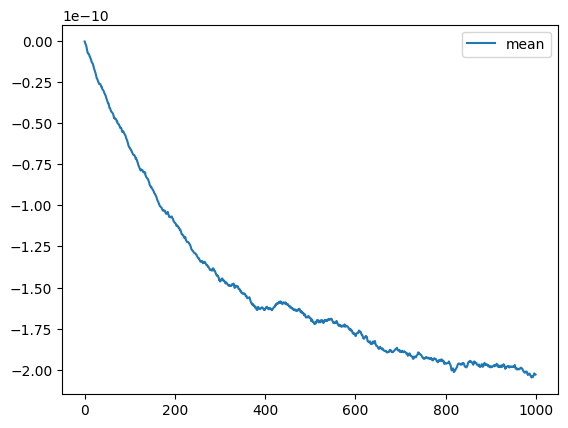

In [107]:
plt.plot([float(m) for m in means], label='mean')
# plt.plot([float(m) for m in maxs], label='max')
# plt.plot([float(m) for m in mins], label='min')
# plt.plot([float(m) for m in stds], label='std')
# plt.yscale('log')
plt.legend()
plt.show()

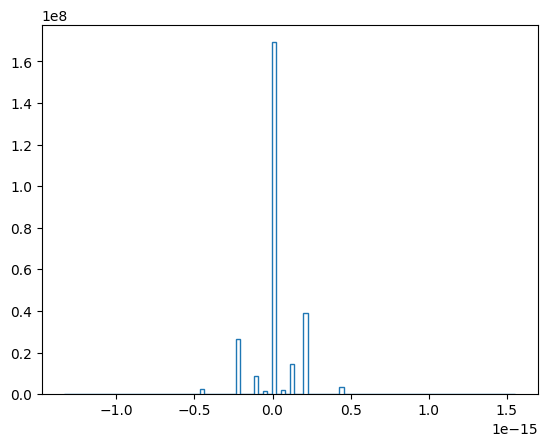

In [93]:
# plt.hist(ds.numpy(), bins=100, histtype='step')
plt.hist(errs.numpy(), bins=100, histtype='step')
# plt.yscale('log')
plt.show()

-2.0712015e-10 1.0729573e-07 1.5497208e-06 -1.66893e-06 (268435456,)


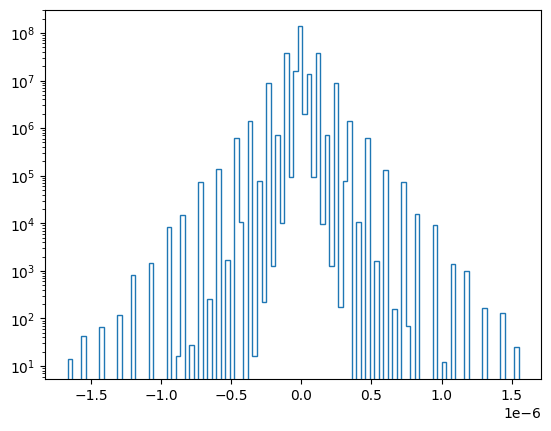

In [85]:
errs_n = errs.numpy()
print(errs_n.mean(), errs_n.std(), errs_n.max(), errs_n.min(), errs_n.shape)
# errs_n = errs_n[np.abs(errs_n) > 1e-6]
# print(errs_n.mean(), errs_n.std(), errs_n.max(), errs_n.min(), errs_n.shape)
# print([f"{s}" for s in errs_n])
plt.hist(errs_n, bins=100, histtype='step')
plt.yscale('log')
plt.show()

In [ ]:

@wp.func
def pow3(x: wp.Float) -> wp.Float:
    return x * x * x

@wp.func
def pow4(x: wp.Float) -> wp.Float:
    return x * x * x * x

@wp.func
def pow5(x: wp.Float) -> wp.Float:
    return x * x * x * x * x

def kernels(vec_type=wp.vec3d, float_type=wp.float64):
    @wp.kernel
    def integrate_conserve2d(particle_x: wp.array(dtype=vec_type), particle_v: wp.array(dtype=vec_type), errs: wp.array(dtype=float_type), grid: wp.uint64, dt: float, seed: int):
        tid = wp.tid()
        state = wp.rand_init(seed, tid)
        i = wp.hash_grid_point_id(grid, tid)  # maybe here
        x = particle_x[i]
        v = particle_v[i]
        diameter = 0.1
        dd = 0.5
        dist_o0 = dd
        dist_o1 = dd * 2.0
        dist_o2 = dd * 3.0
        neighbors = wp.hash_grid_query(grid, wp.vec3f(x), dist_o0)
        if True:
            collision_prob_o0 = dt * diameter * diameter * wp.pi / pow3(dist_o0)
            collision_prob_o1 = dt * diameter * diameter * diameter * wp.pi / 2.0 / pow4(dist_o0)
            collision_prob_o2 = dt * diameter * diameter * diameter * diameter * wp.pi / 8.0 / pow5(dist_o0)
        errrr = float_type(0.0)
        for index in neighbors:
            if index == i:
                continue
            dx = particle_x[i] - particle_x[index]
            dv = particle_v[i] - particle_v[index]
            d = wp.length(dx)
            d2 = wp.length_sq(dx)
            dspeed = wp.length(dv)
            v2old = wp.length_sq(v) + wp.length_sq(particle_v[index])
            dv_dx = wp.dot(dv, dx)
            # if d < dist_o0:
            if wp.randf(state) < collision_prob_o0 * float(dspeed) and dv_dx < 0:
                particle_v[index] += dx * dv_dx / d2
                # wp.atomic_add(particle_v, index, dx * dv_dx / d2)
                particle_v[i] -= dx * dv_dx / d2
                # wp.atomic_add(particle_v, i, - dx * dv_dx / d2)
                # f = f - dx * wp.max(dv_dx / d2, -V_MAX)
                errrr = wp.max(wp.abs(wp.length_sq(particle_v[i]) + wp.length_sq(particle_v[index]) - v2old), errrr)
                break
            # elif d < dist_o1:
            #     if wp.randf(state) < - dv_dx / d * collision_prob_o1:
            #         particle_v[index] += dx * dv_dx / d2
            #         # wp.atomic_add(particle_v, index, dx * dv_dx / d2)
            #         particle_v[i] -= dx * dv_dx / d2
            #         # wp.atomic_add(particle_v, i, - dx * dv_dx / d2)
            #         # f = f - dx * wp.max(dv_dx / d2, -V_MAX)
            #         break
            # elif d < dist_o2:
            #     if wp.randf(state) < - dv_dx * dv_dx / d2 / dspeed * collision_prob_o2:
            #         particle_v[index] += dx * dv_dx / d2
            #         # wp.atomic_add(particle_v, index, dx * dv_dx / d2)
            #         particle_v[i] -= dx * dv_dx / d2
            #         # wp.atomic_add(particle_v, i, - dx * dv_dx / d2)
            #         # f = f - dx * wp.max(dv_dx / d2, -V_MAX)
            #         break
        errs[i] = errrr

    @wp.kernel
    def moving(x: wp.array(dtype=vec_type), xf: wp.array(dtype=wp.vec3f), v: wp.array(dtype=vec_type), dt: float_type, lower: vec_type, length: vec_type):
        tid = wp.tid()
        x[tid] += v[tid] * dt
        dx = x[tid] - lower
        for i in range(3):
            if dx[i] > 16.0:
                x[tid][i] = lower[i] + wp.mod(dx[i], length[i])
            elif dx[i] < 0.0:
                x[tid][i] = lower[i] + length[i] - wp.mod(-dx[i], length[i])
        xf[tid] = wp.vec3f(x[tid])

    @wp.kernel
    def sample_unit_sphere_surface(output: wp.array(dtype=vec_type)):
        tid = wp.tid()
        state = wp.rand_init(0, tid)
        output[tid] = vec_type(wp.sample_unit_sphere_surface(state))

    @wp.kernel
    def sample_cube(output: wp.array(dtype=vec_type), l: float):
        tid = wp.tid()
        state = wp.rand_init(0, tid)
        output[tid] = vec_type(wp.sample_unit_cube(state) * l)
    return integrate_conserve2d, moving, sample_unit_sphere_surface, sample_cube

# N = 2 ** 28

# VEC_TYPE, FLOAT_TYPE = wp.vec3f, wp.float32
VEC_TYPE, FLOAT_TYPE = wp.vec3d, wp.float64
integrate_conserve2d, moving, sample_unit_sphere_surface, sample_cube = kernels(VEC_TYPE, FLOAT_TYPE)

N = 131072
grid = wp.HashGrid(32, 32, 32)
xs = wp.array(dtype=VEC_TYPE, shape=(N,))
xsf = wp.array(dtype=wp.vec3f, shape=(N,))
vs = wp.array(dtype=VEC_TYPE, shape=(N,))
wp.launch(kernel=sample_cube, dim=N, inputs=[xs, 16.0])
wp.launch(kernel=sample_unit_sphere_surface, dim=N, inputs=[vs])
m = 1.0
errs = wp.array(dtype=FLOAT_TYPE, shape=(N,))
means = []
bx = FLOAT_TYPE(-8)
lx = FLOAT_TYPE(16)
for i in tqdm(range(1000)):
    grid.build(xsf, 0.77)
    wp.launch(kernel=integrate_conserve2d, dim=N, inputs=[xs, vs, errs, grid.id, 0.005, i])
    wp.launch(kernel=moving, dim=N, inputs=[xs, xsf, vs, 0.005, VEC_TYPE(bx, bx, bx), VEC_TYPE(lx, lx, lx)])
    means.append((wp.to_torch(vs)**2).mean())


Module __main__ 5b6f064 load on device 'cuda:0' took 12.34 ms


WarpCodegenError: Error while parsing function "integrate_conserve2d" at C:\Users\hy-wu.DESKTOP-G355NC5\AppData\Local\Temp\ipykernel_15536\3105922843.py:49:
            wp.synchronize_device("cuda") 
;Could not find function wp.synchronize_device as a built-in or user-defined function. Note that user functions must be annotated with a @wp.func decorator to be called from a kernel.

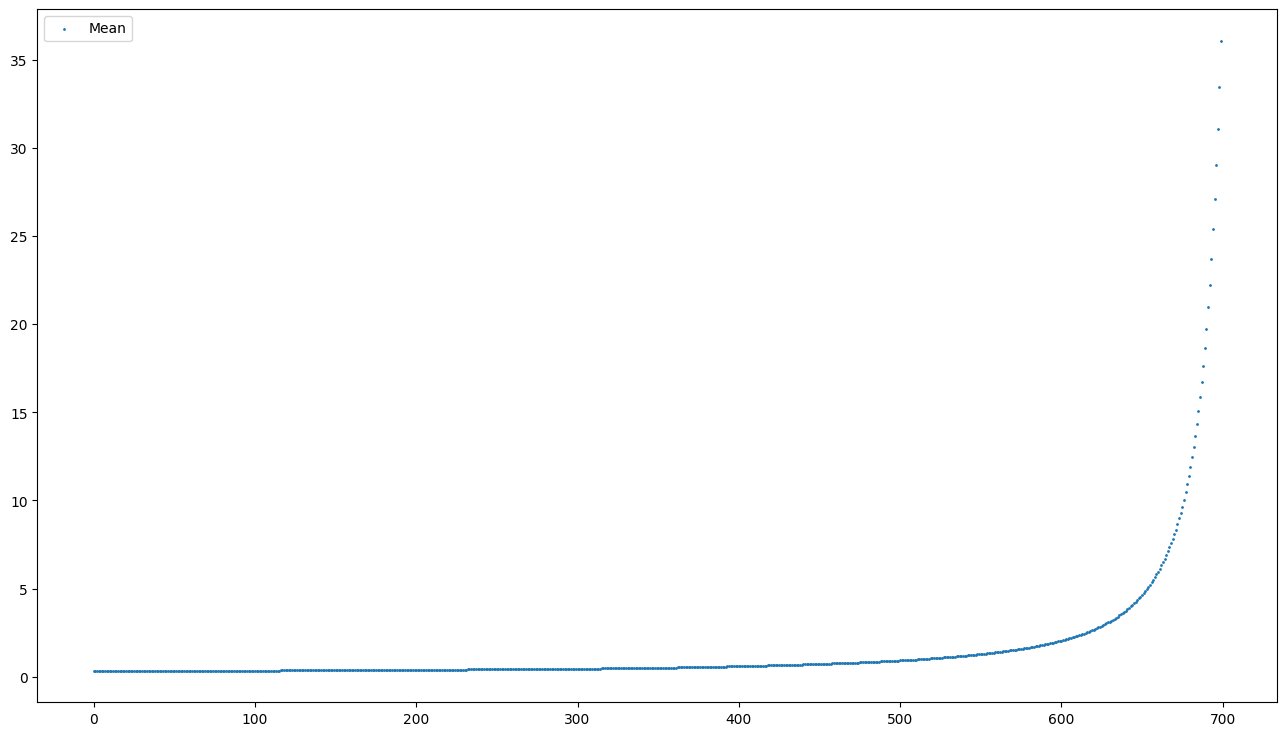

In [6]:

plt.figure(figsize=(16, 9))
means = [float(s) if np.isfinite(s) else 0 for s in means[:700]]
plt.scatter(range(len(means)), means, s=1, label='Mean')
w = 100
# plt.plot(range(w-1, len(means)), np.convolve(means, np.ones(w), "valid") / w, linewidth=1, label='Pooled Mean', color='orange')
plt.legend()
plt.show()

inf nan inf 0.0 (131072,)


c:\Users\hy-wu.DESKTOP-G355NC5\AppData\Local\Programs\Python\Python312\Lib\site-packages\numpy\core\_methods.py:173: RuntimeWarning: invalid value encountered in subtract
  x = asanyarray(arr - arrmean)


ValueError: supplied range of [0.0, inf] is not finite

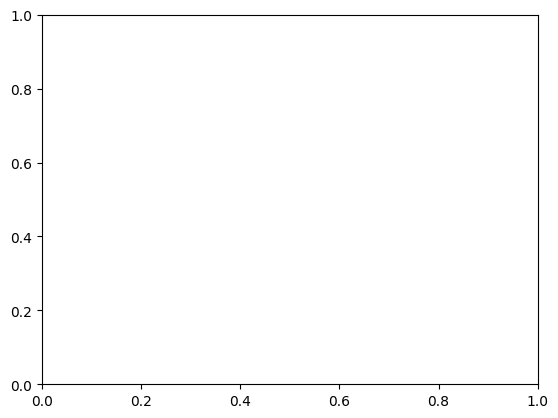

In [7]:
errs_n = errs.numpy()
print(errs_n.mean(), errs_n.std(), errs_n.max(), errs_n.min(), errs_n.shape)
# errs_n = errs_n[np.abs(errs_n) > 1e-6]
# print(errs_n.mean(), errs_n.std(), errs_n.max(), errs_n.min(), errs_n.shape)
# print([f"{s}" for s in errs_n])
plt.hist(errs_n, bins=100, histtype='step')
plt.yscale('log')
plt.show()

In [27]:
plt.hist(xs.numpy()[:,0], bins=100, histtype='step')
plt.show()

NameError: name 'xs' is not defined

In [ ]:
max(means)

0.3333333432674408

In [ ]:
xs.numpy()[:,0].min(), xs.numpy()[:,0].max(), xs.numpy()[:,0].shape

(-999.9799, 999.97943, (16777216,))

In [ ]:
(wp.to_torch(xs)**2).mean()

tensor(85.3241, device='cuda:0')

  0%|          | 0/1000 [00:00<?, ?it/s]

Module __main__ f9f94c6 load on device 'cuda:0' took 319.05 ms  (compiled)


100%|██████████| 1000/1000 [00:23<00:00, 42.06it/s]


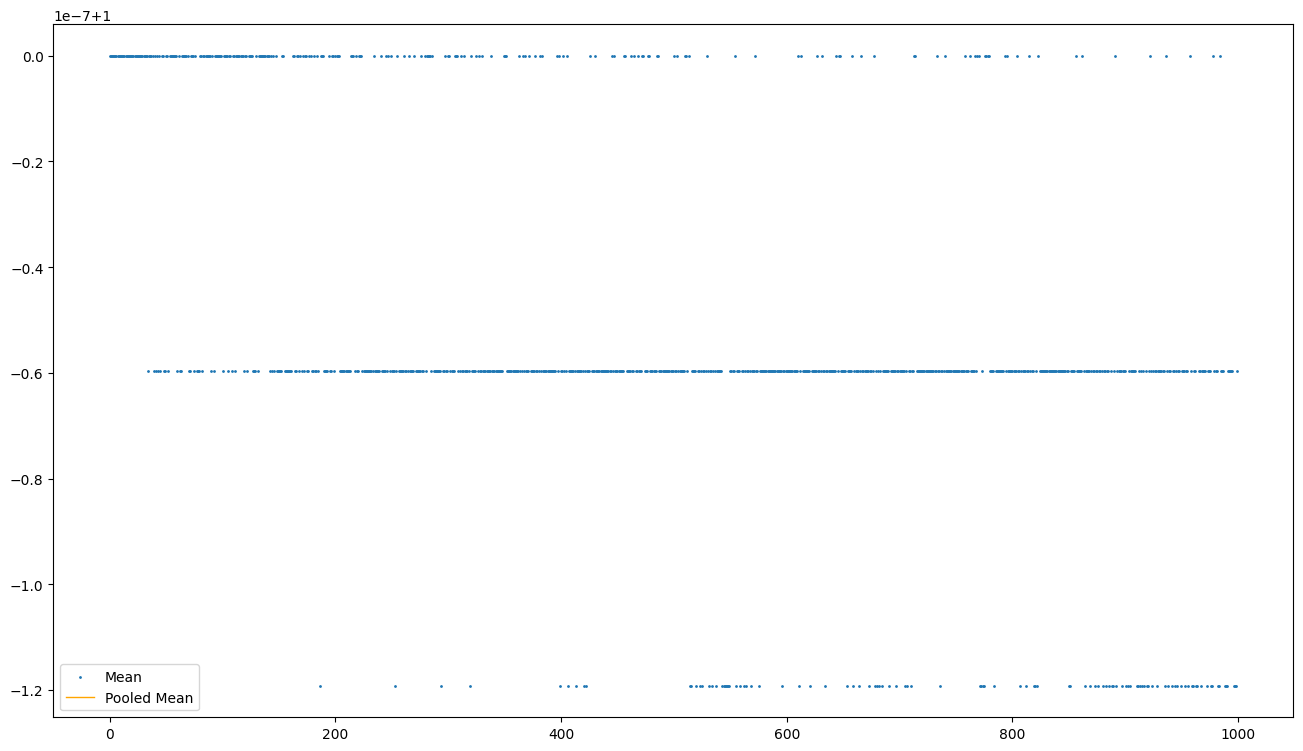

In [ ]:
@wp.kernel
def integrate_conserve2d(x: wp.array(dtype=float), halfN: int):
    tid = wp.tid()
    state = wp.rand_init(0, tid)
    x0 = x[tid]
    x1 = x[tid+halfN]
    sq = x0 * x0 + x1 * x1
    x0 *= wp.randf(state)
    x[tid] = x0
    x[tid+halfN] = wp.sqrt(sq - (x0 * x0))

N = 2 ** 30
xs = wp.ones(dtype=float, shape=(N,))
means = []
for i in tqdm(range(1000)):
    wp.launch(kernel=integrate_conserve2d, dim=N//2, inputs=[xs, N//2])
    means.append((wp.to_torch(xs)**2).mean())

plt.figure(figsize=(16, 9))
means = [float(s) for s in means]
plt.scatter(range(len(means)), means, s=1, label='Mean')
w = 1000
plt.plot(range(w-1, len(means)), np.convolve(means, np.ones(w), "valid") / w, linewidth=1, label='Pooled Mean', color='orange')
plt.legend()
plt.show()

In [ ]:
@wp.kernel
def integrate_conserve1d(x: wp.array(dtype=float), halfN: int):
    tid = wp.tid()
    state = wp.rand_init(0, tid)
    diff = wp.randf(state)
    x[tid] -= diff
    x[tid+halfN] += diff

N = 16777216
xs = wp.ones(dtype=float, shape=(N,))
sums = []
for i in tqdm(range(100000)):
    wp.launch(kernel=integrate_conserve1d, dim=N//2, inputs=[xs, N//2])
    sums.append(wp.to_torch(xs).mean())

  0%|          | 0/100000 [00:00<?, ?it/s]

Module __main__ 0da1f9b load on device 'cuda:0' took 0.92 ms  (cached)


100%|██████████| 100000/100000 [00:41<00:00, 2389.87it/s]


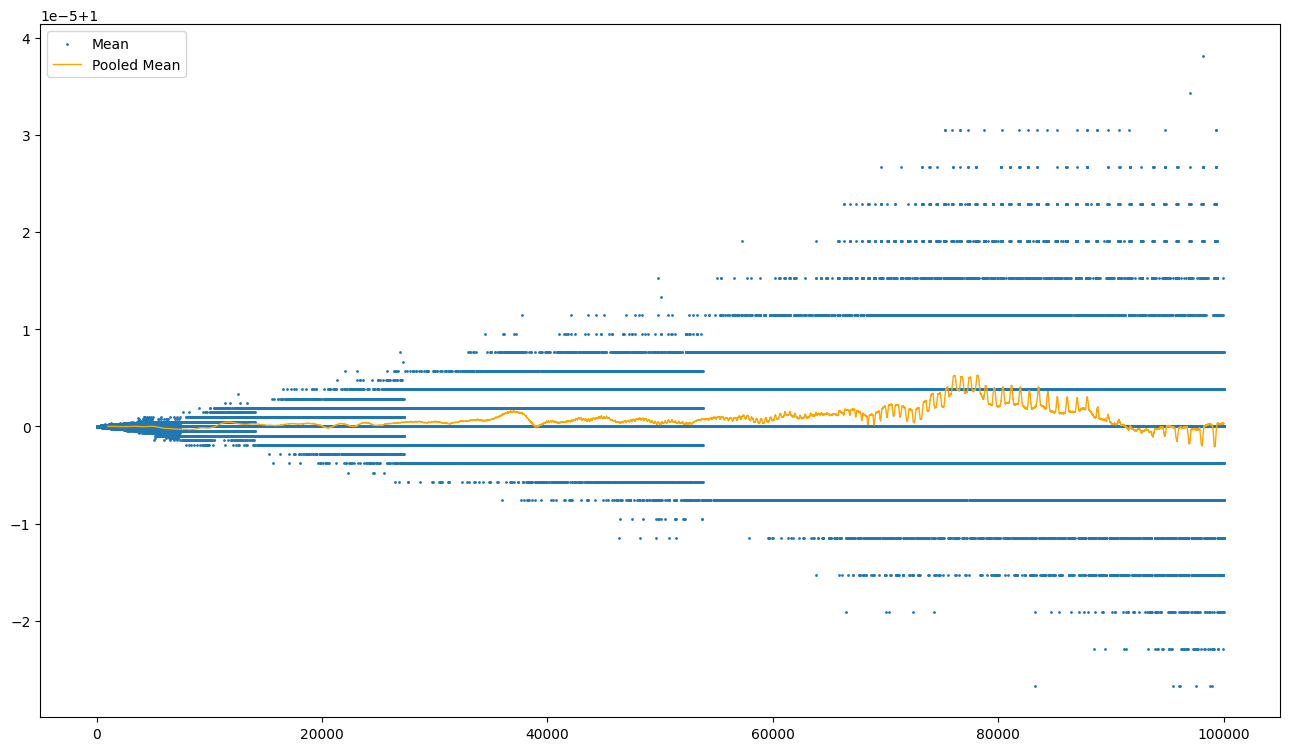

In [ ]:
plt.figure(figsize=(16, 9))
sums = [float(s) for s in sums]
plt.scatter(range(len(sums)), sums, s=1, label='Mean')
w = 1000
plt.plot(range(w-1, len(sums)), np.convolve(sums, np.ones(w), "valid") / w, linewidth=1, label='Pooled Mean', color='orange')
plt.legend()
plt.show()

In [ ]:
2 ** 30

1073741824

In [ ]:
sums

[1.0,
 0.9999999403953552,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 

In [ ]:
@wp.kernel
def sample_unit_sphere_surface(output: wp.array(dtype=wp.vec3)):
    tid = wp.tid()
    state = wp.rand_init(0, tid)
    output[tid] = wp.sample_unit_sphere_surface(state)

N = 16777216
vs = wp.array(dtype=wp.vec3, shape=(N,))
wp.launch(kernel=sample_unit_sphere_surface, dim=N, inputs=[vs])
m = 1.0

Module __main__ 50f1ad8 load on device 'cuda:0' took 20.33 ms  (cached)


In [ ]:
@wp.kernel
def len3(input: wp.array(dtype=wp.vec3), output: wp.array(dtype=float)):
    tid = wp.tid()
    output[tid] = wp.length(input[tid])

speeds = wp.array(dtype=float, shape=(N,))
wp.launch(kernel=len3, dim=N, inputs=[vs, speeds])

Module __main__ cba4fdd load on device 'cuda:0' took 419.01 ms  (compiled)


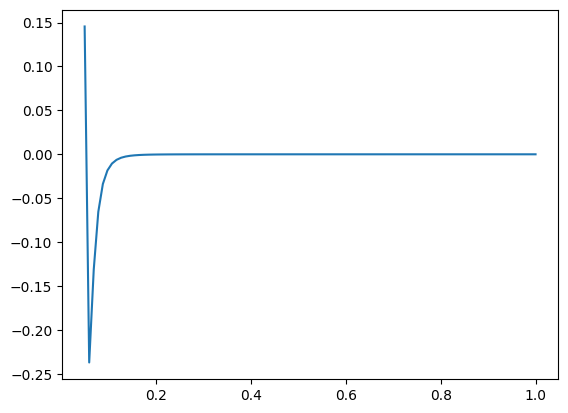

In [26]:
d = diameter = 0.05
l_j_epsilon = 1
def l_j_potential(r):
    return l_j_epsilon * ((d / r)**12 - (d / r)**6)
plt.plot(np.linspace(0.049, 1, 100), l_j_potential(np.linspace(0.049, 1, 100)))

In [2]:
24.0 * 1 * (2.0 * (0.1 * 0.1 / 0.25) ** 6 - (0.1 * 0.1 / 0.25)) ** 3 * 0.5 / 0.25

-0.0030719981125635876